In [8]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, accuracy_score, 
    f1_score, roc_auc_score, classification_report
)

warnings.filterwarnings("ignore")

BASE_MODEL_DIR = r"C:\mutation\models"
BASE_DATA_DIR = r"C:\mutation\data\processed"

print("🚀 ML Evaluation Environment Ready.\n")

🚀 ML Evaluation Environment Ready.



Data Loading & Pipeline Preparation

In [9]:
print("📦 Loading data...")

features_df = pd.read_csv(os.path.join(BASE_DATA_DIR, "final_gene_features.csv"))

if "pathogenic" not in features_df.columns:
    features_df["pathogenic"] = features_df["label"]

ML_DROP = {"GeneSymbol", "description", "label", "pathogenic_variants", "pathogenic"}
ml_cols = [c for c in features_df.columns if c not in ML_DROP and pd.api.types.is_numeric_dtype(features_df[c])]

X = features_df[ml_cols].values.astype(np.float32)
y = features_df["label"].values.astype(int)

# Train/Test split (same as training)
train_idx, test_idx, y_train, y_test = train_test_split(
    np.arange(len(y)), y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Dataset ready. Test samples: {len(test_idx)}\n")

📦 Loading data...
✅ Dataset ready. Test samples: 4610



Load Models & Evaluate

In [10]:
scaler_path = os.path.join(BASE_MODEL_DIR, "ml_feature_scaler.pkl")

scaler = joblib.load(scaler_path) if os.path.exists(scaler_path) else None

if scaler is None or getattr(scaler, "n_features_in_", None) != len(ml_cols):
    print("⚠️ Fitting new scaler (train only)...")
    scaler = StandardScaler()
    scaler.fit(X[train_idx])

X_test = scaler.transform(X[test_idx])
X_test_df = pd.DataFrame(X_test, columns=ml_cols)

print("✅ Scaling complete.\n")

⚠️ Fitting new scaler (train only)...
✅ Scaling complete.



In [11]:
print("🤖 Loading models...")

models = {
    "Logistic Regression": joblib.load(os.path.join(BASE_MODEL_DIR, "logistic_regression.pkl")),
    "SVM": joblib.load(os.path.join(BASE_MODEL_DIR, "svm.pkl")),
    "Random Forest": joblib.load(os.path.join(BASE_MODEL_DIR, "random_forest.pkl")),
    "Gradient Boost": joblib.load(os.path.join(BASE_MODEL_DIR, "gradient_boost.pkl")),
    "XGBoost": joblib.load(os.path.join(BASE_MODEL_DIR, "xgboost.pkl")),
    "Stacking Ensemble": joblib.load(os.path.join(BASE_MODEL_DIR, "stacking_ensemble.pkl"))
}

print("✅ Models loaded.\n")


🤖 Loading models...
✅ Models loaded.



In [12]:
summary = []

for name, model in models.items():
    print("=" * 60)
    print(f"🧬 Evaluating: {name}")
    print("=" * 60)

    # Get probabilities
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_df)[:, 1]
    else:
        dec = model.decision_function(X_test_df)
        probs = 1 / (1 + np.exp(-dec))

    # Optimal threshold (maximize F1)
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    opt_thresh = thresholds[np.argmax(f1_scores)]

    preds = (probs >= opt_thresh).astype(int)

    # Metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    summary.append({
        "Model": name,
        "Threshold": round(opt_thresh, 2),
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

    print(f"Optimal Threshold: {opt_thresh:.2f}")
    print(f"Accuracy: {acc:.4f}  |  F1-Score: {f1:.4f}  |  ROC-AUC: {auc:.4f}\n")
    print(classification_report(y_test, preds))

🧬 Evaluating: Logistic Regression
Optimal Threshold: 0.50
Accuracy: 0.7662  |  F1-Score: 0.7298  |  ROC-AUC: 0.8548

              precision    recall  f1-score   support

           0       0.92      0.70      0.79      2983
           1       0.62      0.89      0.73      1627

    accuracy                           0.77      4610
   macro avg       0.77      0.80      0.76      4610
weighted avg       0.82      0.77      0.77      4610

🧬 Evaluating: SVM
Optimal Threshold: 0.68
Accuracy: 0.7939  |  F1-Score: 0.7031  |  ROC-AUC: 0.8386

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      2983
           1       0.72      0.69      0.70      1627

    accuracy                           0.79      4610
   macro avg       0.77      0.77      0.77      4610
weighted avg       0.79      0.79      0.79      4610

🧬 Evaluating: Random Forest
Optimal Threshold: 0.43
Accuracy: 0.8297  |  F1-Score: 0.7843  |  ROC-AUC: 0.9083

              pre

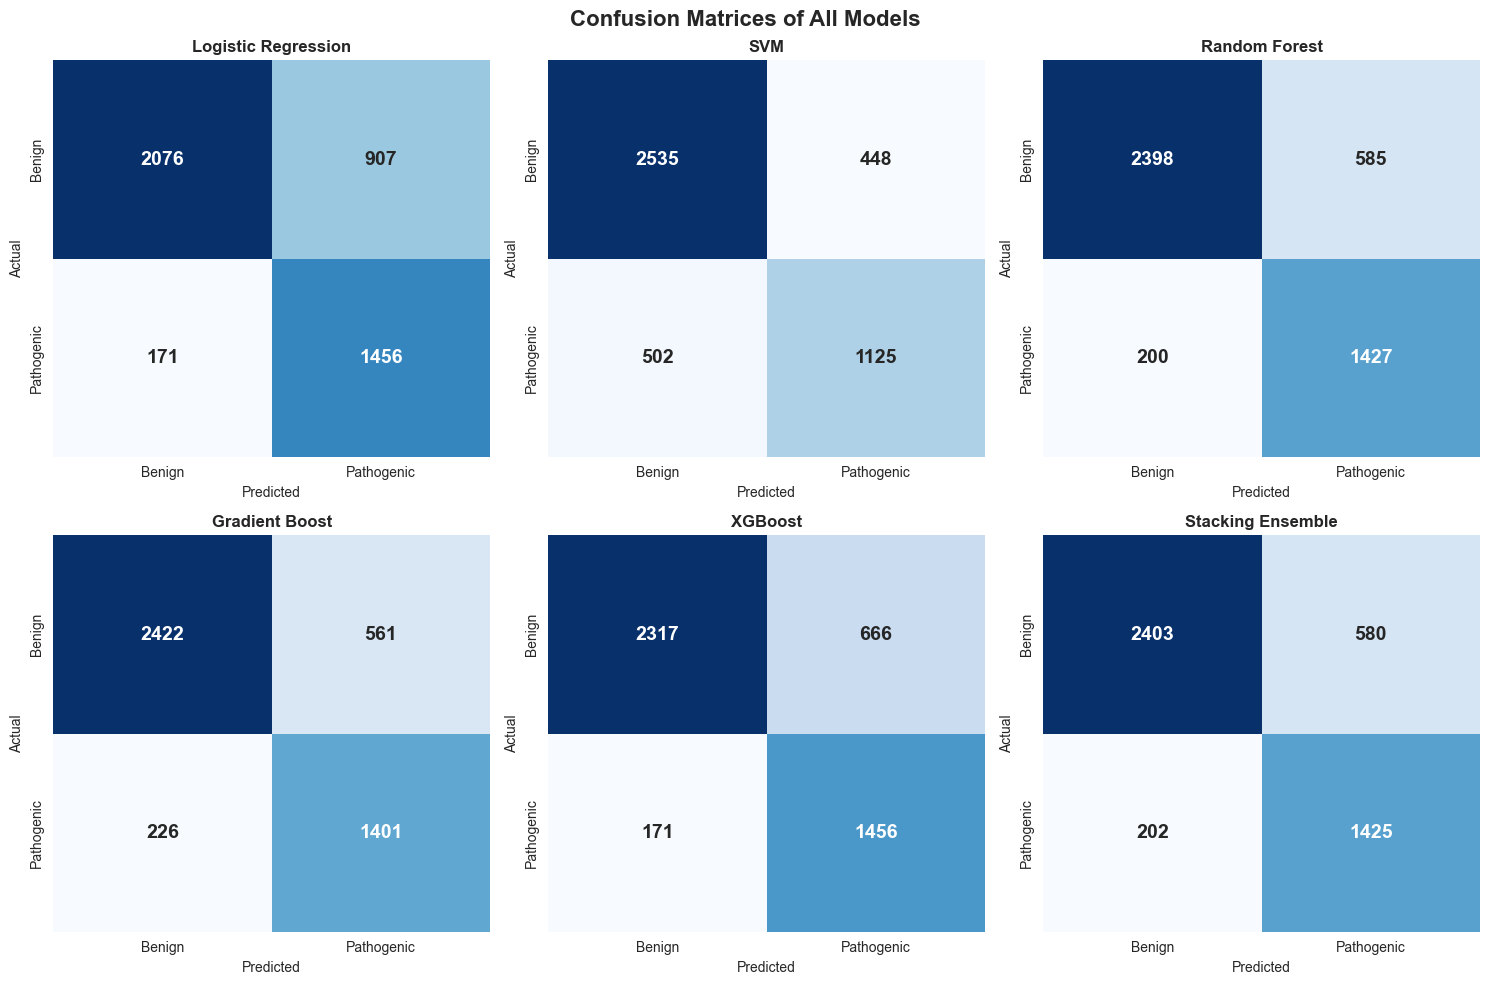

In [13]:
all_preds = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_df)[:, 1]
    else:
        dec = model.decision_function(X_test_df)
        probs = 1 / (1 + np.exp(-dec))

    # Same threshold logic (important!)
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    opt_thresh = thresholds[np.argmax(f1_scores)]

    preds = (probs >= opt_thresh).astype(int)
    all_preds[name] = preds


# ==========================================================
# PLOT ALL CONFUSION MATRICES IN ONE FIGURE (2x3 GRID)
# ==========================================================
sns.set_style("white")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[i],
        xticklabels=['Benign', 'Pathogenic'],
        yticklabels=['Benign', 'Pathogenic'],
        annot_kws={"size": 14, "weight": "bold"}
    )

    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# If less than 6 models, remove extra plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrices of All Models", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

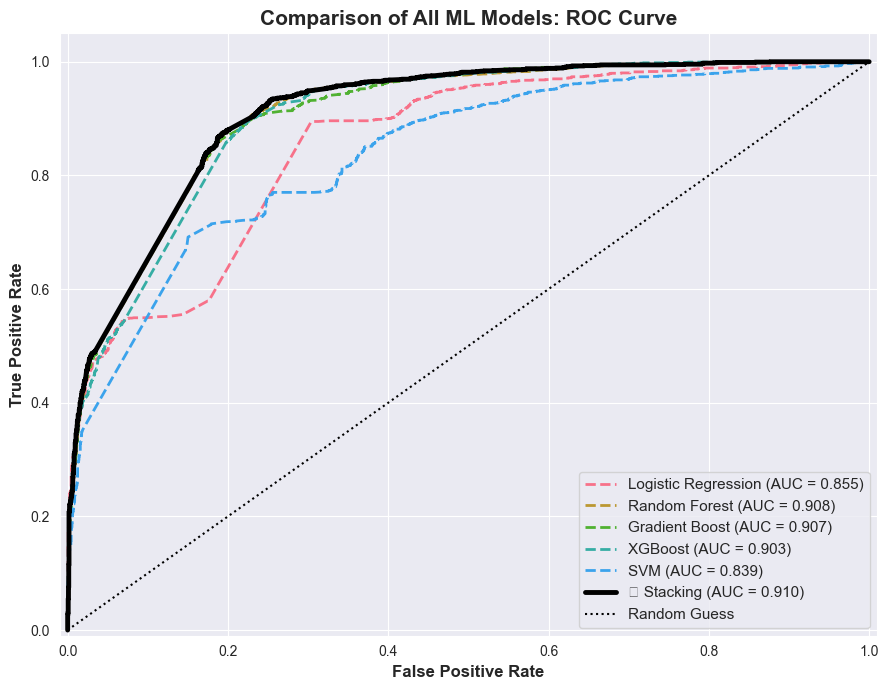

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
plt.figure(figsize=(9, 7))

# ✅ Use roc_curves instead of tuned_models
colors = sns.color_palette("husl", len(roc_curves))

for i, (name, (fpr, tpr, auc)) in enumerate(roc_curves.items()):
    
    # Highlight ensemble
    if name == "Stacking":
        plt.plot(fpr, tpr, color='black', linestyle='-', lw=3.5,
                 label=f"★ {name} (AUC = {auc:.3f})")
    else:
        plt.plot(fpr, tpr, color=colors[i], linestyle='--', lw=2,
                 label=f"{name} (AUC = {auc:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], 'k:', lw=1.5, label='Random Guess')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.05])

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Comparison of All ML Models: ROC Curve', fontsize=15, fontweight='bold')

plt.legend(loc="lower right", fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

🔬 Running inference & finding optimal thresholds...


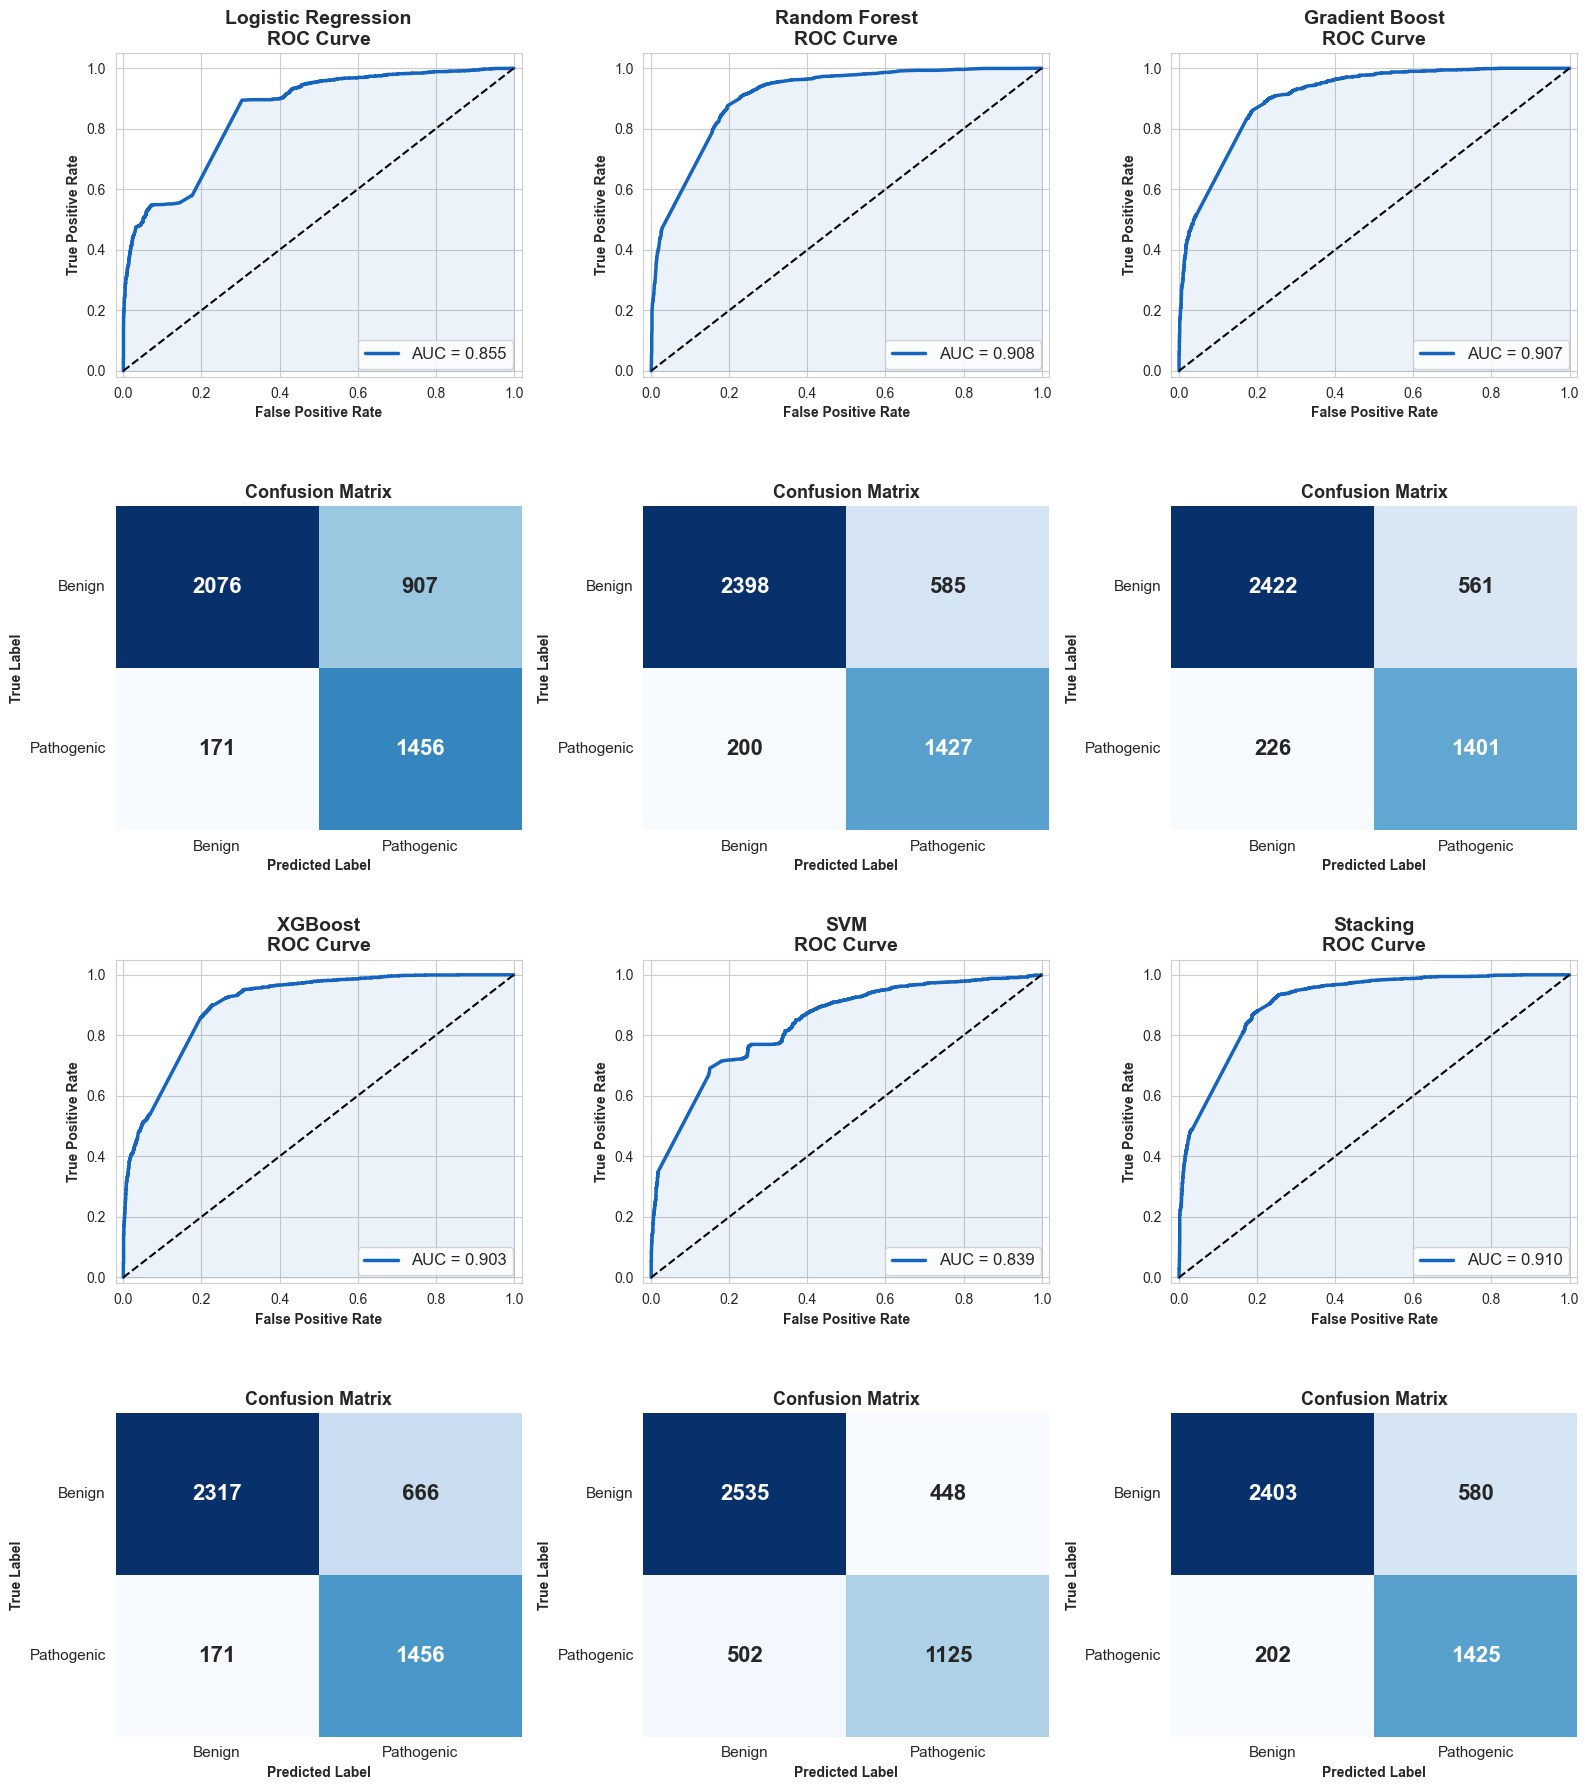


🏆 ML MODELS LEADERBOARD 🏆


,Model,AUC,F1
0,Stacking,0.910391,0.784692
1,Random Forest,0.908261,0.784281
2,Gradient Boost,0.907137,0.780719
3,XGBoost,0.902982,0.776740
4,Logistic Regression,0.854783,0.729825
5,SVM,0.838586,0.703125


In [18]:
import joblib
import os

MODEL_PATH = r"C:\mutation\models"

tuned_models = {
    "Logistic Regression": joblib.load(os.path.join(MODEL_PATH, "logistic_regression.pkl")),
    "Random Forest": joblib.load(os.path.join(MODEL_PATH, "random_forest.pkl")),
    "Gradient Boost": joblib.load(os.path.join(MODEL_PATH, "gradient_boost.pkl")),
    "XGBoost": joblib.load(os.path.join(MODEL_PATH, "xgboost.pkl")),
    "SVM": joblib.load(os.path.join(MODEL_PATH, "svm.pkl")),
    "Stacking": joblib.load(os.path.join(MODEL_PATH, "stacking_ensemble.pkl")),
}
roc_curves = {}
model_preds = {}
summary_data = []

print("🔬 Running inference & finding optimal thresholds...")
for name, model in tuned_models.items():
    # Get probabilities
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_df)[:, 1] 
    else:
        dec = model.decision_function(X_test_df)
        probs = 1 / (1 + np.exp(-dec))

    # Optimal Threshold
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    opt_thresh = thresholds[np.argmax(f1_scores)]
    preds = (probs >= opt_thresh).astype(int)
    
    # Save for plotting
    model_preds[name] = preds
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_curves[name] = (fpr, tpr, roc_auc_score(y_test, probs))
    summary_data.append({"Model": name, "AUC": roc_auc_score(y_test, probs), "F1": f1_score(y_test, preds)})

# ==========================================================
# 4. PLOT MASTER 4x3 GRID (ROC + Confusion Matrix)
# ==========================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
models_list = list(tuned_models.keys())

for i, name in enumerate(models_list):
    # Calculate grid position (3 columns wide)
    # ROC curves go on rows 0 and 2. CMs go on rows 1 and 3.
    r_roc = (i // 3) * 2
    c = i % 3
    r_cm = r_roc + 1
    
    ax_roc = axes[r_roc, c]
    ax_cm = axes[r_cm, c]
    
    # --- A. PLOT ROC CURVE ---
    fpr, tpr, auc = roc_curves[name]
    ax_roc.plot(fpr, tpr, color='#1565C0', lw=2.5, label=f'AUC = {auc:.3f}')
    ax_roc.plot([0, 1], [0, 1], color='black', linestyle='--', lw=1.5)
    ax_roc.fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
    
    ax_roc.set_title(f'{name}\nROC Curve', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
    ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
    ax_roc.set_xlim([-0.02, 1.02])
    ax_roc.set_ylim([-0.02, 1.05])
    ax_roc.legend(loc='lower right', frameon=True, fontsize=12)
    
    # --- B. PLOT CONFUSION MATRIX ---
    preds = model_preds[name]
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, 
                cbar=False, annot_kws={"size": 16, "weight": "bold"})
    
    ax_cm.set_title(f'Confusion Matrix', fontsize=13, fontweight='bold')
    ax_cm.set_xlabel('Predicted Label', fontweight='bold')
    ax_cm.set_ylabel('True Label', fontweight='bold')
    ax_cm.set_xticklabels(['Benign', 'Pathogenic'], fontsize=11)
    ax_cm.set_yticklabels(['Benign', 'Pathogenic'], rotation=0, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

# Print quick summary leaderboard below the plot
print("\n🏆 ML MODELS LEADERBOARD 🏆")
display(pd.DataFrame(summary_data).sort_values(by="F1", ascending=False).reset_index(drop=True).style.background_gradient(cmap='Blues'))

📦 Loading data and all 6 ML models...
🧬 Running Final Clinical & Statistical Validation Suite for ALL Models...
   -> Running 1,000 Bootstrap iterations (this may take a few seconds)...


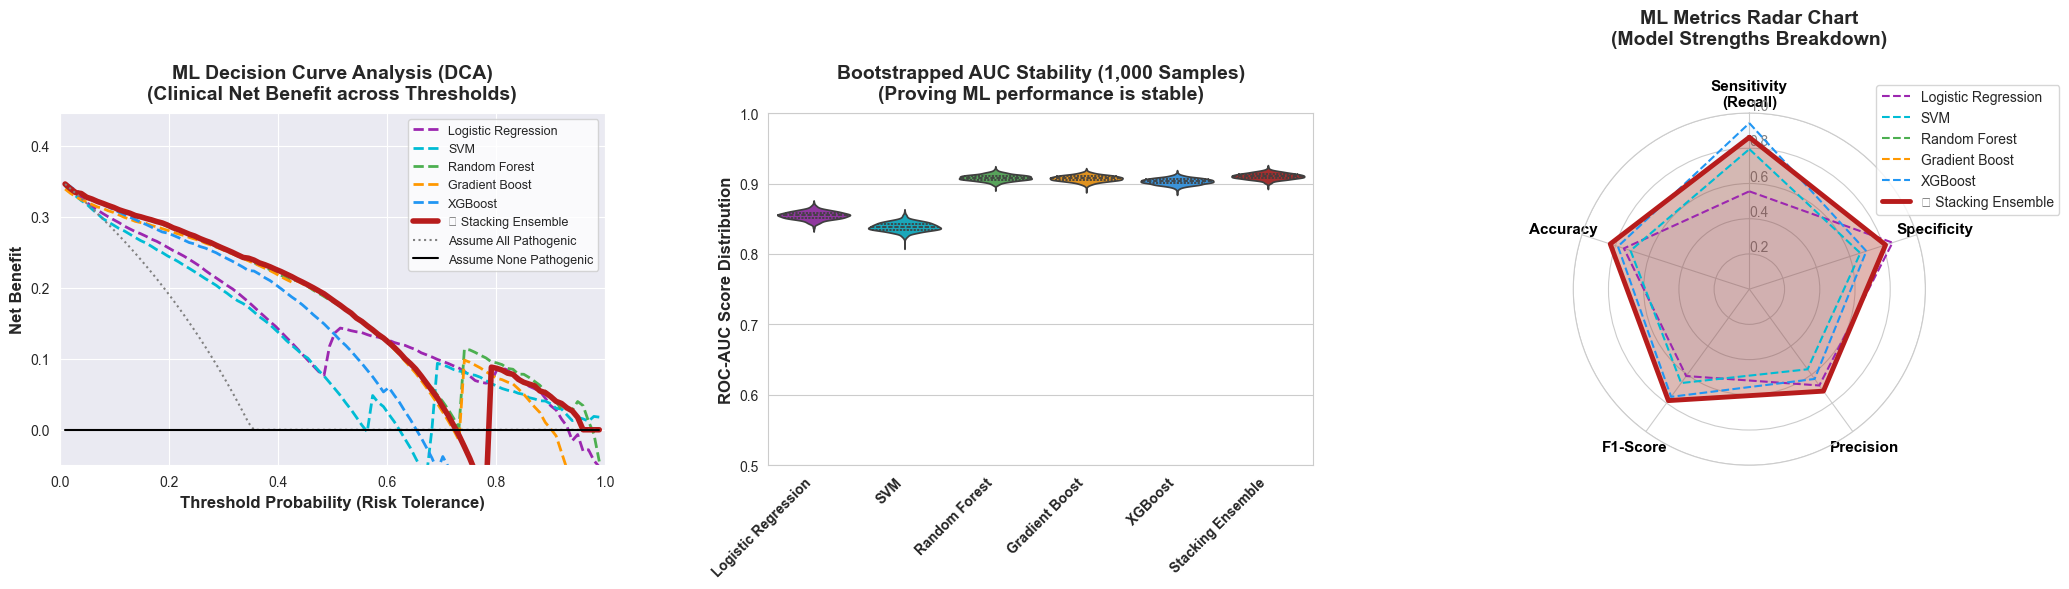

In [16]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample
from math import pi

# ==========================================================
# 0. LOAD DATA, SCALERS, AND ALL 6 MODELS
# ==========================================================
print("📦 Loading data and all 6 ML models...")
BASE_DATA_DIR = r"C:\mutation\data\processed"
BASE_MODEL_DIR = r"C:\mutation\models"

features_df = pd.read_csv(os.path.join(BASE_DATA_DIR, "final_gene_features.csv"))
if "pathogenic" not in features_df.columns:
    features_df["pathogenic"] = features_df["label"]

ML_DROP = {"GeneSymbol", "description", "label", "pathogenic_variants", "pathogenic"}
ml_cols = [c for c in features_df.columns if c not in ML_DROP and pd.api.types.is_numeric_dtype(features_df[c])]

X_raw = features_df[ml_cols].values.astype(np.float32)
y_test_full = features_df["label"].values.astype(int)

train_idx, test_idx, _, y_test = train_test_split(
    np.arange(len(y_test_full)), y_test_full, test_size=0.2, random_state=42, stratify=y_test_full
)

# Safe Scaler
ml_scaler_path = os.path.join(BASE_MODEL_DIR, "ml_feature_scaler.pkl")
scaler = joblib.load(ml_scaler_path) if os.path.exists(ml_scaler_path) else None
if scaler is None or getattr(scaler, "n_features_in_", None) != len(ml_cols):
    scaler = StandardScaler()
    scaler.fit(X_raw[train_idx]) 

X_test_scaled = scaler.transform(X_raw[test_idx])
X_test_df = pd.DataFrame(X_test_scaled, columns=ml_cols)

# Load ALL 6 Models
tuned_models = {
    "Logistic Regression": joblib.load(os.path.join(BASE_MODEL_DIR, "logistic_regression.pkl")),
    "SVM": joblib.load(os.path.join(BASE_MODEL_DIR, "svm.pkl")),
    "Random Forest": joblib.load(os.path.join(BASE_MODEL_DIR, "random_forest.pkl")),
    "Gradient Boost": joblib.load(os.path.join(BASE_MODEL_DIR, "gradient_boost.pkl")),
    "XGBoost": joblib.load(os.path.join(BASE_MODEL_DIR, "xgboost.pkl")),
    "Stacking Ensemble": joblib.load(os.path.join(BASE_MODEL_DIR, "stacking_ensemble.pkl"))
}
model_names = list(tuned_models.keys())

# Define a distinct color palette for 6 models
colors = ['#9C27B0', '#00BCD4', '#4CAF50', '#FF9800', '#2196F3', '#B71C1C'] 

# ==========================================================
# 1. EXTRACT PROBABILITIES
# ==========================================================
print("🧬 Running Final Clinical & Statistical Validation Suite for ALL Models...")
ml_probs = {}

for name in model_names:
    model = tuned_models[name]
    if hasattr(model, "predict_proba"):
        ml_probs[name] = model.predict_proba(X_test_df)[:, 1]
    else:
        dec = model.decision_function(X_test_df)
        ml_probs[name] = 1 / (1 + np.exp(-dec))

# ==========================================================
# 2. DECISION CURVE ANALYSIS (DCA)
# ==========================================================
def calculate_net_benefit(y_true, y_probs, thresholds):
    net_benefits = []
    N = len(y_true)
    for pt in thresholds:
        preds = (y_probs >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        if pt == 1.0: pt = 0.999 
        net_benefit = (tp / N) - (fp / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)
    return np.array(net_benefits)

thresholds = np.linspace(0.01, 0.99, 100)
prevalence = np.sum(y_test) / len(y_test)

nb_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))
nb_all = np.maximum(nb_all, 0)
nb_none = np.zeros_like(thresholds)

nb_dict = {name: calculate_net_benefit(y_test, ml_probs[name], thresholds) for name in model_names}

# ==========================================================
# 3. BOOTSTRAPPED CONFIDENCE INTERVALS
# ==========================================================
print("   -> Running 1,000 Bootstrap iterations (this may take a few seconds)...")
bootstrap_aucs = {m: [] for m in model_names}

for i in range(1000):
    indices = resample(np.arange(len(y_test)), replace=True, random_state=i)
    if len(np.unique(y_test[indices])) < 2: continue 
    
    for name in model_names:
        bootstrap_aucs[name].append(roc_auc_score(y_test[indices], ml_probs[name][indices]))

boot_df = pd.DataFrame(bootstrap_aucs)

# ==========================================================
# 4. METRICS FOR RADAR CHART
# ==========================================================
def get_radar_metrics(y_true, probs):
    preds = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn) if (tp+fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn+fp) > 0 else 0
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision+sensitivity) > 0 else 0
    acc = (tp + tn) / len(y_true)
    return [sensitivity, specificity, precision, f1, acc]

categories = ['Sensitivity\n(Recall)', 'Specificity', 'Precision', 'F1-Score', 'Accuracy']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] 

radar_dict = {name: get_radar_metrics(y_test, ml_probs[name]) + [get_radar_metrics(y_test, ml_probs[name])[0]] for name in model_names}

# ==========================================================
# 5. PLOTTING THE 1x3 MASTER RESEARCH SUITE
# ==========================================================
fig = plt.figure(figsize=(22, 6))

# --- PLOT A: DCA ---
ax1 = fig.add_subplot(1, 3, 1)
sns.set_style("whitegrid")

for i, name in enumerate(model_names):
    lw = 4 if "Ensemble" in name else 2
    ls = '-' if "Ensemble" in name else '--'
    prefix = "★ " if "Ensemble" in name else ""
    ax1.plot(thresholds, nb_dict[name], color=colors[i], lw=lw, linestyle=ls, label=f'{prefix}{name}')

ax1.plot(thresholds, nb_all, color='gray', lw=1.5, linestyle=':', label='Assume All Pathogenic')
ax1.plot(thresholds, nb_none, color='black', lw=1.5, linestyle='-', label='Assume None Pathogenic')

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([-0.05, max(nb_dict["Stacking Ensemble"]) + 0.1])
ax1.set_title('ML Decision Curve Analysis (DCA)\n(Clinical Net Benefit across Thresholds)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Threshold Probability (Risk Tolerance)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9, frameon=True)

# --- PLOT B: Violin Plots ---
ax2 = fig.add_subplot(1, 3, 2)
sns.violinplot(data=boot_df, palette=colors, ax=ax2, inner="quartile")
ax2.set_title('Bootstrapped AUC Stability (1,000 Samples)\n(Proving ML performance is stable)', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('ROC-AUC Score Distribution', fontsize=12, fontweight='bold')
ax2.set_ylim([0.5, 1.0])
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontweight='bold')

# --- PLOT C: Radar Chart ---
ax3 = fig.add_subplot(1, 3, 3, polar=True)
ax3.set_theta_offset(pi / 2)
ax3.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='black', size=11, fontweight='bold')
ax3.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.0)

for i, name in enumerate(model_names):
    lw = 3.5 if "Ensemble" in name else 1.5
    ls = 'solid' if "Ensemble" in name else 'dashed'
    alpha_fill = 0.25 if "Ensemble" in name else 0.05
    prefix = "★ " if "Ensemble" in name else ""
    
    ax3.plot(angles, radar_dict[name], color=colors[i], linewidth=lw, linestyle=ls, label=f'{prefix}{name}')
    ax3.fill(angles, radar_dict[name], color=colors[i], alpha=alpha_fill)

ax3.set_title('ML Metrics Radar Chart\n(Model Strengths Breakdown)', fontsize=14, fontweight='bold', pad=25)
ax3.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

📊 Generating ML Research Visualizations...


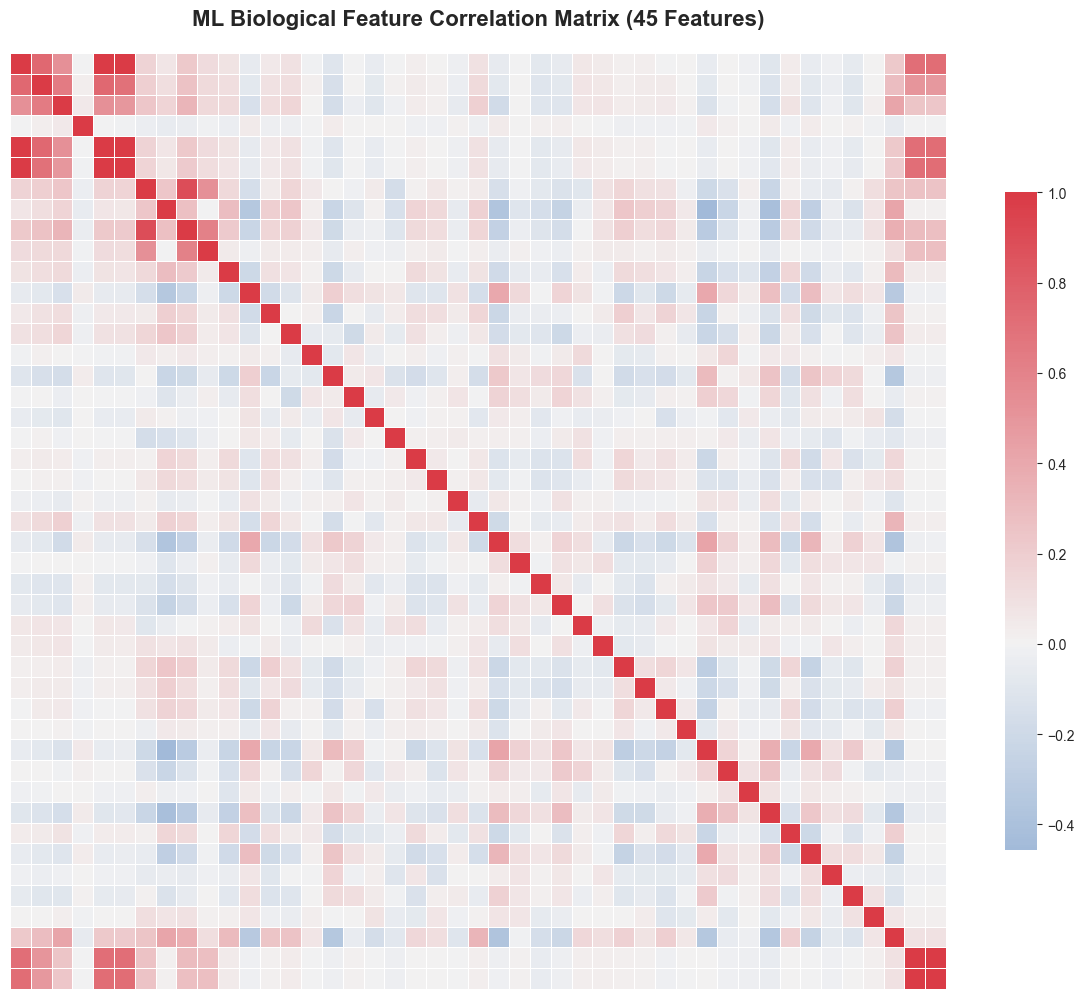

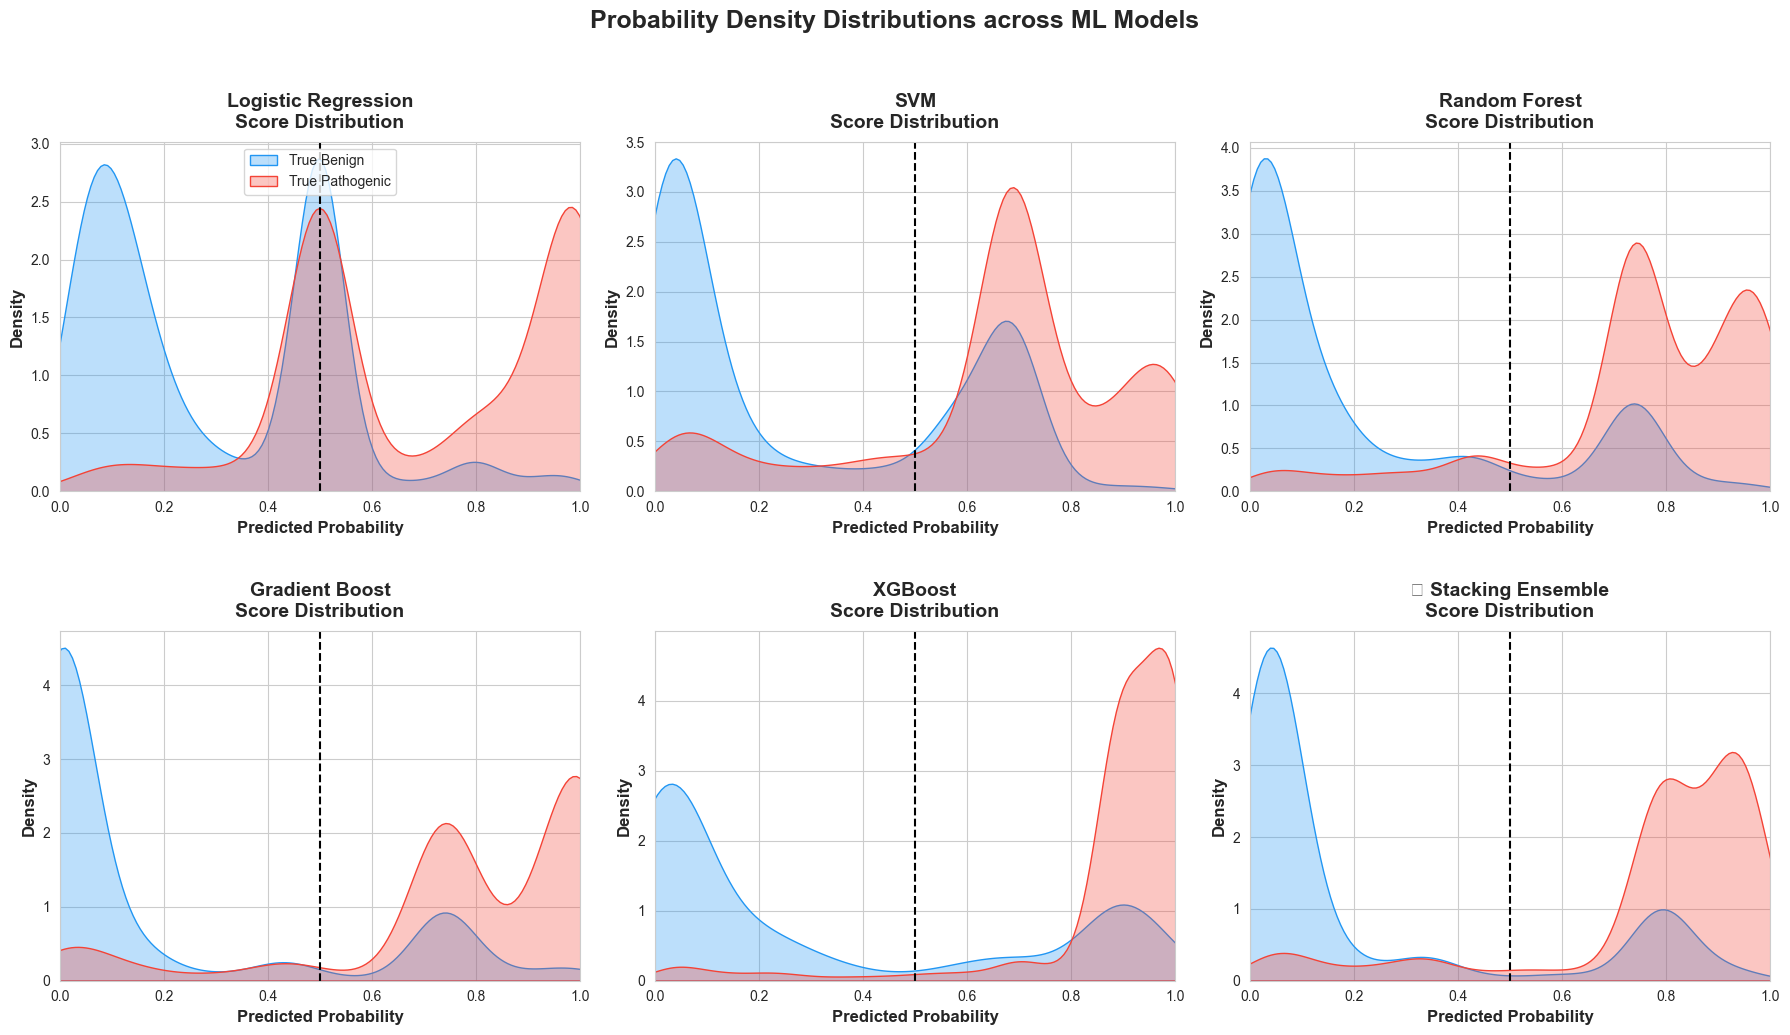

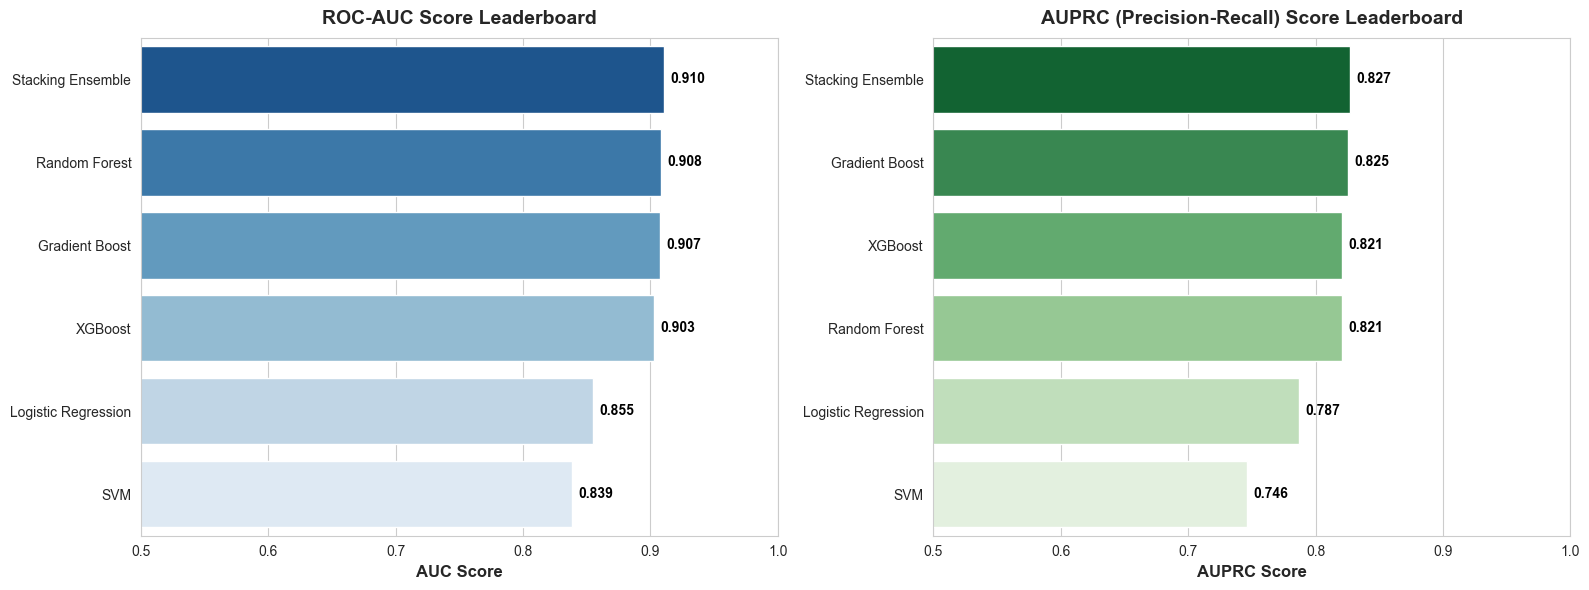

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

print("📊 Generating ML Research Visualizations...")
sns.set_style("whitegrid")

# ==========================================================
# 1. FEATURE CORRELATION HEATMAP (For the 45 ML Features)
# ==========================================================
# Calculate the correlation matrix
corr_matrix = features_df[ml_cols].corr()

plt.figure(figsize=(12, 10))
sns.set_style("white")

# Use a professional blue-to-red divergent colormap
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr_matrix, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, 
            xticklabels=False, yticklabels=False)

plt.title("ML Biological Feature Correlation Matrix (45 Features)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================================
# 2. MODEL SCORE DENSITY DISTRIBUTIONS (2x3 Grid)
# ==========================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(model_names):
    ax = axes[i]
    probs = ml_probs[name]
    prefix = "★ " if "Ensemble" in name else ""
    
    # Plot True Benign (Label 0) in Blue
    sns.kdeplot(probs[y_test == 0], fill=True, color="#2196F3", alpha=0.3, label="True Benign", ax=ax)
    
    # Plot True Pathogenic (Label 1) in Red
    sns.kdeplot(probs[y_test == 1], fill=True, color="#F44336", alpha=0.3, label="True Pathogenic", ax=ax)
    
    # Decision boundary line
    ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5) 
    
    ax.set_title(f'{prefix}{name}\nScore Distribution', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_xlim([0.0, 1.0])
    
    # Put legend only on the first plot to keep the grid clean
    if i == 0:
        ax.legend(loc="upper center", frameon=True, fontsize=10)

plt.suptitle("Probability Density Distributions across ML Models", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

# ==========================================================
# 3. HORIZONTAL BAR CHARTS (AUC & AUPRC Leaderboards)
# ==========================================================
# Calculate metrics for all 6 models
auc_scores = [roc_auc_score(y_test, ml_probs[name]) for name in model_names]
auprc_scores = [average_precision_score(y_test, ml_probs[name]) for name in model_names]

bar_data = pd.DataFrame({
    "Model": model_names,
    "AUC": auc_scores,
    "AUPRC": auprc_scores
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: AUC Score (Sorted Highest to Lowest) ---
bar_data_auc = bar_data.sort_values(by="AUC", ascending=False)
sns.barplot(x="AUC", y="Model", data=bar_data_auc, ax=axes[0], palette="Blues_r")

axes[0].set_title('ROC-AUC Score Leaderboard', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('AUC Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_xlim([0.5, 1.0]) # Zoom in for clarity

# Add text labels right at the end of the bars
for i, v in enumerate(bar_data_auc["AUC"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center', fontweight='bold', color='black')

# --- Plot B: AUPRC Score (Sorted Highest to Lowest) ---
bar_data_pr = bar_data.sort_values(by="AUPRC", ascending=False)
sns.barplot(x="AUPRC", y="Model", data=bar_data_pr, ax=axes[1], palette="Greens_r")

axes[1].set_title('AUPRC (Precision-Recall) Score Leaderboard', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('AUPRC Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlim([0.5, 1.0])

for i, v in enumerate(bar_data_pr["AUPRC"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [10]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops, k_hop_subgraph
from torch_geometric.nn import SAGEConv, GATv2Conv
import torch.nn.functional as F
import warnings

from torch_geometric.explain import Explainer, GNNExplainer

warnings.filterwarnings('ignore')

# ==========================================
# GPU MEMORY CLEANUP FUNCTION
# ==========================================
def clean_gpu_memory():
    if torch.cuda.is_available():
        print("\n🧹 Cleaning GPU memory...")
        print(f"Before -> Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB | Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
        
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        
        print(f"After  -> Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB | Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB\n")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
BASE_DATA_DIR = r"C:\mutation\data\processed"
BASE_MODEL_DIR = r"C:\mutation\models"

# GPU STRICT CHECK
if not torch.cuda.is_available():
    raise RuntimeError("❌ CUDA GPU is NOT available. Code is forced to run only on GPU.")

print("✅ CUDA is available")
print("GPU Name:", torch.cuda.get_device_name(0))
print("CUDA Version:", torch.version.cuda)
print("PyTorch CUDA:", torch.backends.cudnn.version())

device = torch.device("cuda:0")

TARGET_GENE = "BRCA1"

print(f"Loading data to explain the AI's decision for {TARGET_GENE}...")
features_df = pd.read_csv(os.path.join(BASE_DATA_DIR, "final_gene_features.csv"))
edges_df = pd.read_csv(os.path.join(BASE_DATA_DIR, "final_edge_list.csv"))

GNN_DROP = {"GeneSymbol", "description", "label", "pathogenic_variants", "pathogenic", 
            "neighbor_pathogenic_ratio", "mutation_network_score", "rare_network_score", 
            "gene_degree", "clustering_coefficient", "pagerank", "betweenness_centrality"}

gnn_cols = [c for c in features_df.columns if c not in GNN_DROP and pd.api.types.is_numeric_dtype(features_df[c])]

# Scale features
gnn_scaler = StandardScaler()
X_gnn_scaled = gnn_scaler.fit_transform(features_df[gnn_cols].values.astype(np.float32))

# Build Graph Map
genes = features_df["GeneSymbol"].tolist()
g2i = {g: i for i, g in enumerate(genes)}
i2g = {i: g for i, g in enumerate(genes)}

if TARGET_GENE not in g2i:
    raise ValueError(f"Gene {TARGET_GENE} not found in the dataset!")

target_node_idx = g2i[TARGET_GENE]

valid_edges = [[g2i[r.gene1], g2i[r.gene2]] for r in edges_df.itertuples()
               if r.gene1 in g2i and r.gene2 in g2i]

edge_index = torch.tensor(valid_edges, dtype=torch.long).t().contiguous()
edge_index = to_undirected(edge_index)
edge_index, _ = add_self_loops(edge_index, num_nodes=len(genes))

graph_data = Data(
    x=torch.tensor(X_gnn_scaled, dtype=torch.float),
    edge_index=edge_index
).to(device)

# ==========================================
# 2. LOAD MODEL
# ==========================================
class GeneGAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=128, heads=8):
        super().__init__()
        self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.3)
        self.ln1   = torch.nn.LayerNorm(hidden_dim * heads)
        self.conv2 = GATv2Conv(hidden_dim * heads, 2, heads=1, concat=False)
        self.skip  = torch.nn.Linear(input_dim, hidden_dim * heads)

    def forward(self, x, edge_index):
        x1 = self.conv1(x, edge_index) + self.skip(x)
        x1 = F.elu(self.ln1(x1))
        x1 = F.dropout(x1, p=0.4, training=self.training)
        return self.conv2(x1, edge_index)

gat_model = GeneGAT(input_dim=len(gnn_cols)).to(device)
gat_model.load_state_dict(torch.load(os.path.join(BASE_MODEL_DIR, "gene_gat_model.pt"), map_location=device))
gat_model.eval()

# ✅ Clean GPU after loading model
clean_gpu_memory()

# ==========================================
# 3. EXPLAINER
# ==========================================
print("Running GNNExplainer...")

# ✅ Clean before heavy step
clean_gpu_memory()

explainer = Explainer(
    model=gat_model,
    algorithm=GNNExplainer(epochs=5),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

explanation = explainer(graph_data.x, graph_data.edge_index, index=target_node_idx)

# ✅ Clean after explainer
clean_gpu_memory()

node_mask = explanation.node_mask.cpu().numpy()
edge_mask = explanation.edge_mask.cpu().numpy()

# ==========================================
# 4. FEATURE IMPORTANCE
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

feature_importance = node_mask[target_node_idx]
top_indices = np.argsort(feature_importance)[::-1][:10]
top_features = [gnn_cols[i] for i in top_indices]
top_scores = feature_importance[top_indices]

sns.barplot(x=top_scores, y=top_features, palette="viridis", ax=axes[0])

axes[0].set_title(f"What the AI looked at inside {TARGET_GENE}")
axes[0].set_xlabel("Feature Importance")
axes[0].set_ylabel("Features")

# ==========================================
# 5. IMPROVED GRAPH VISUALIZATION (2D + 3D)
# ==========================================

import plotly.graph_objects as go

# 🔥 STEP 1: Filter important edges (TOP-K)
top_k = 20  # you can tune (10–25 best for clarity)

edge_list = []
for i in range(sub_edge_index.shape[1]):
    src = subset_genes[sub_edge_index[0, i].item()]
    dst = subset_genes[sub_edge_index[1, i].item()]
    weight = sub_edge_weights[i]

    if src != dst and weight > 0.1:
        edge_list.append((src, dst, weight))

# Sort and keep top edges
edge_list = sorted(edge_list, key=lambda x: x[2], reverse=True)[:top_k]

# Build filtered graph
G_filtered = nx.Graph()
for u, v, w in edge_list:
    G_filtered.add_edge(u, v, weight=w)

# ==========================================
# 🔵 2D CLEAN VISUALIZATION (MATPLOTLIB)
# ==========================================

pos = nx.spring_layout(G_filtered, k=0.8, seed=42)

edges = G_filtered.edges(data=True)
weights = [e[2]['weight'] * 5 for e in edges]

node_colors = ['#d32f2f' if node == TARGET_GENE else '#64b5f6'
               for node in G_filtered.nodes()]

node_sizes = [1500 if node == TARGET_GENE else 800
              for node in G_filtered.nodes()]

# Show labels only for important nodes
top_nodes = list(set([u for u,_,_ in edge_list] + [v for _,v,_ in edge_list]))[:10]
labels = {node: node if node in top_nodes or node == TARGET_GENE else "" 
          for node in G_filtered.nodes()}

nx.draw_networkx_nodes(G_filtered, pos,
                       node_color=node_colors,
                       node_size=node_sizes,
                       edgecolors='black',
                       ax=axes[1])

nx.draw_networkx_edges(G_filtered, pos,
                       width=weights,
                       edge_color='gray',
                       alpha=0.7,
                       ax=axes[1])

nx.draw_networkx_labels(G_filtered, pos,
                        labels=labels,
                        font_size=9,
                        font_weight="bold",
                        font_color='black',
                        ax=axes[1])

axes[1].set_title(f"Top Influential Neighbor Genes for {TARGET_GENE}")
axes[1].axis('off')


# ==========================================
# 🔴 3D INTERACTIVE VISUALIZATION (PLOTLY)
# ==========================================

pos_3d = nx.spring_layout(G_filtered, dim=3, seed=42)

# Node positions
x_nodes = [pos_3d[n][0] for n in G_filtered.nodes()]
y_nodes = [pos_3d[n][1] for n in G_filtered.nodes()]
z_nodes = [pos_3d[n][2] for n in G_filtered.nodes()]

# Edges
edge_x, edge_y, edge_z = [], [], []

for edge in G_filtered.edges():
    x0, y0, z0 = pos_3d[edge[0]]
    x1, y1, z1 = pos_3d[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

fig_3d = go.Figure()

# Edges
fig_3d.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(width=2, color='gray'),
    hoverinfo='none'
))

# Nodes
fig_3d.add_trace(go.Scatter3d(
    x=x_nodes, y=y_nodes, z=z_nodes,
    mode='markers+text',
    text=list(G_filtered.nodes()),
    textposition="top center",
    marker=dict(
        size=8,
        color=['red' if n == TARGET_GENE else 'blue'
               for n in G_filtered.nodes()]
    )
))

fig_3d.update_layout(
    title=f"3D Gene Interaction Network ({TARGET_GENE})",
    showlegend=False,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_3d.show()
# ==========================================
# SAVE
# ==========================================
plt.tight_layout()
save_path = os.path.join(BASE_DATA_DIR, "..", f"gnnexplainer_{TARGET_GENE}.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"✅ Saved to: {os.path.abspath(save_path)}")

✅ CUDA is available
GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA Version: 11.8
PyTorch CUDA: 90100
Loading data to explain the AI's decision for BRCA1...

🧹 Cleaning GPU memory...
Before -> Allocated: 0.04 GB | Reserved: 0.05 GB
After  -> Allocated: 0.04 GB | Reserved: 0.05 GB

Running GNNExplainer...

🧹 Cleaning GPU memory...
Before -> Allocated: 0.04 GB | Reserved: 0.05 GB
After  -> Allocated: 0.04 GB | Reserved: 0.05 GB



KeyboardInterrupt: 